In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")

dataset = pd.read_excel("HousePricePrediction.xlsx")


In [3]:
print("Dataset shape:", dataset.shape)

dataset.info()

Dataset shape: (2919, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [4]:
obj_cols = dataset.select_dtypes(include=["object"]).columns.tolist()

int_cols = dataset.select_dtypes(include=["int64"]).columns.tolist()

float_cols = dataset.select_dtypes(include=["float64"]).columns.tolist()

print("Categorical variables:", obj_cols)
print("Integer variables:", int_cols)
print("Float variables:", float_cols)

Categorical variables: ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
Integer variables: ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd']
Float variables: ['BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


## Корреляции числовых признаков с целевой переменной

Корреляция показывает, насколько два числовых признака связаны друг с другом.

- Значение около 1 означает сильную положительную связь.
- Значение около -1 означает сильную отрицательную связь.
- Значение около 0 означает слабую линейную связь.

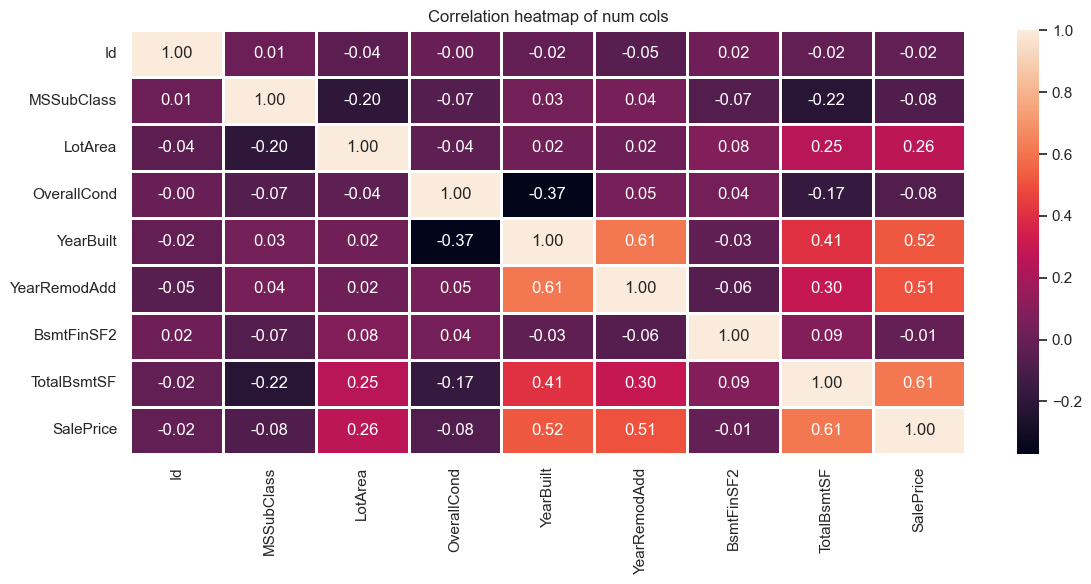

In [5]:
numerical_cols = dataset.select_dtypes(include=["Int64", "Float64"])

plt.figure(figsize=(12, 6))

sns.heatmap(
    numerical_cols.corr(), # матрица корреляций
    fmt=".2f",
    linewidths=2,
    annot=True
)   

plt.title("Correlation heatmap of num cols")

plt.tight_layout()

plt.show()

## Категориальные признаки

Смотрим сколько уникальных значений есть в каждом категориальном столбце

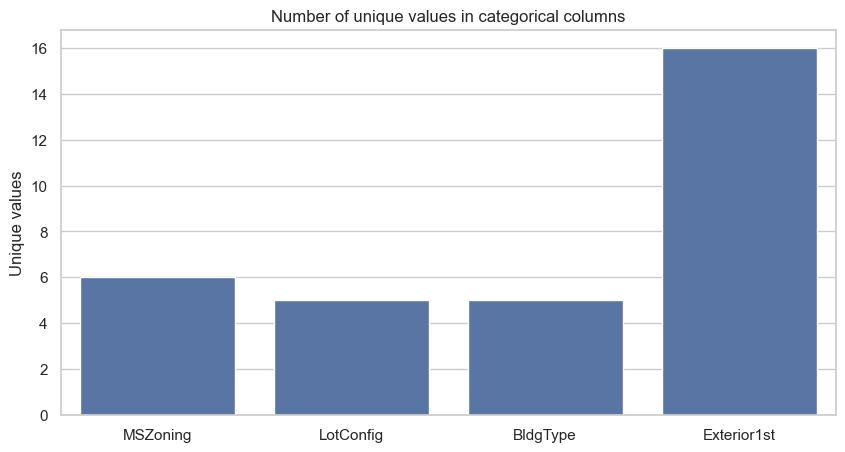

In [6]:
unqie_values = [dataset[col].nunique(dropna=False) for col in obj_cols]

plt.figure(figsize=(10, 5))

sns.barplot(x=obj_cols, y=unqie_values)

plt.title("Number of unique values in categorical columns")

plt.ylabel("Unique values")

plt.show()

Подробнее: сколько раз встречаются конкретные значения в каждой из 4-х категорий 

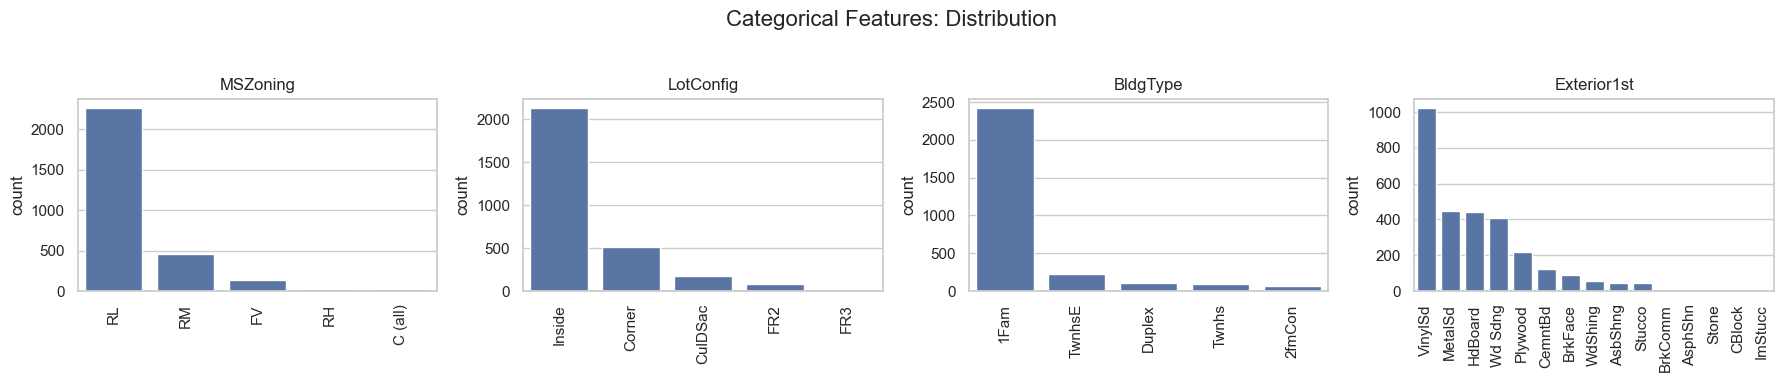

In [7]:
import math

n_cols = 4
n_rows = math.ceil(len(obj_cols) / n_cols)

plt.figure(figsize=(18, n_rows * 4))
plt.suptitle('Categorical Features: Distribution', fontsize=16) 

for index, col in enumerate(obj_cols, 1):
    y = dataset[col].value_counts(dropna=False)
    plt.subplot(n_rows, n_cols, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    plt.title(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
